In [ ]:
import os
from tensorflow.keras import layers
from tensorflow.keras import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
from google.colab import drive

drive.mount('/content/drive')
directory = '/content/drive/MyDrive/Monkeypox Skin Image Dataset v6'

Mounted at /content/drive


##Data Exploration

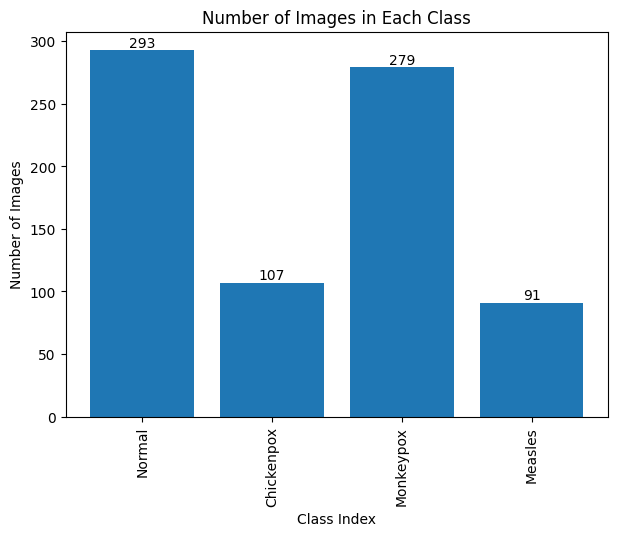

In [ ]:
import os
import matplotlib.pyplot as plt

def plot_dataset():
    class_names = os.listdir(directory)
    new_num_images = []
    for class_name in class_names:
        class_path = os.path.join(directory, class_name)
        new_num_images.append(len(os.listdir(class_path)))

    plt.figure(figsize=(7, 5))
    plt.bar(range(len(class_names)), new_num_images)
    plt.title('Number of Images in Each Class')
    plt.xlabel('Class Index')
    plt.ylabel('Number of Images')
    plt.xticks(range(len(class_names)), class_names, rotation=90)

    for i, num_images in enumerate(new_num_images):
        plt.text(i, num_images, str(num_images), ha='center', va='bottom')

    plt.show()

plot_dataset()

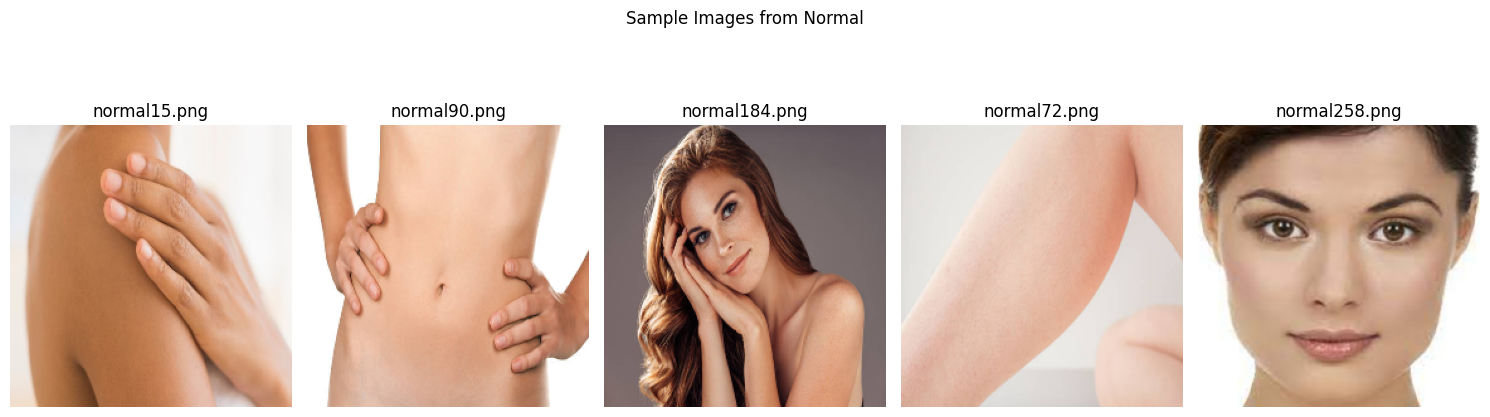

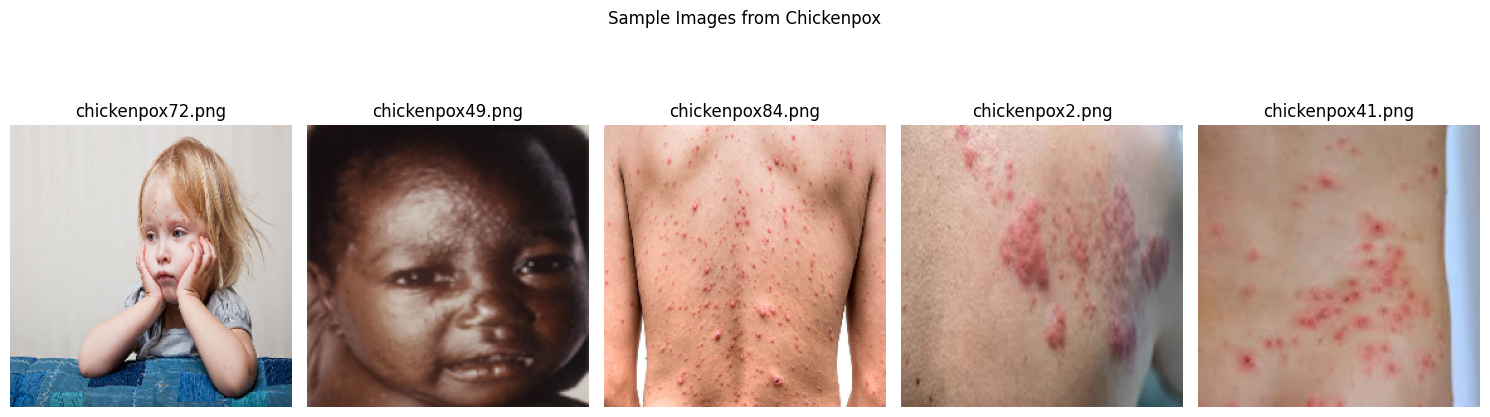

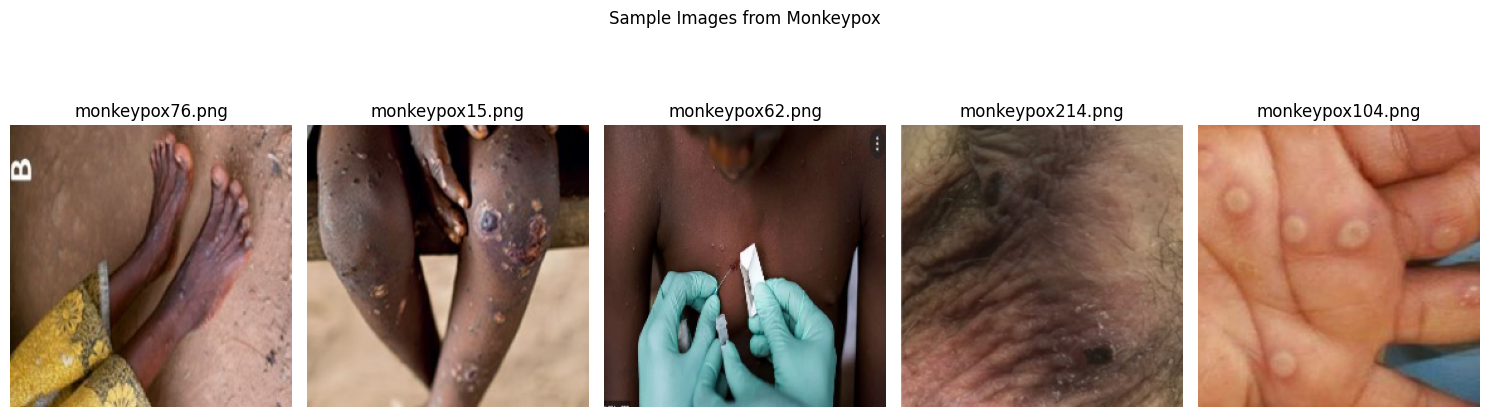

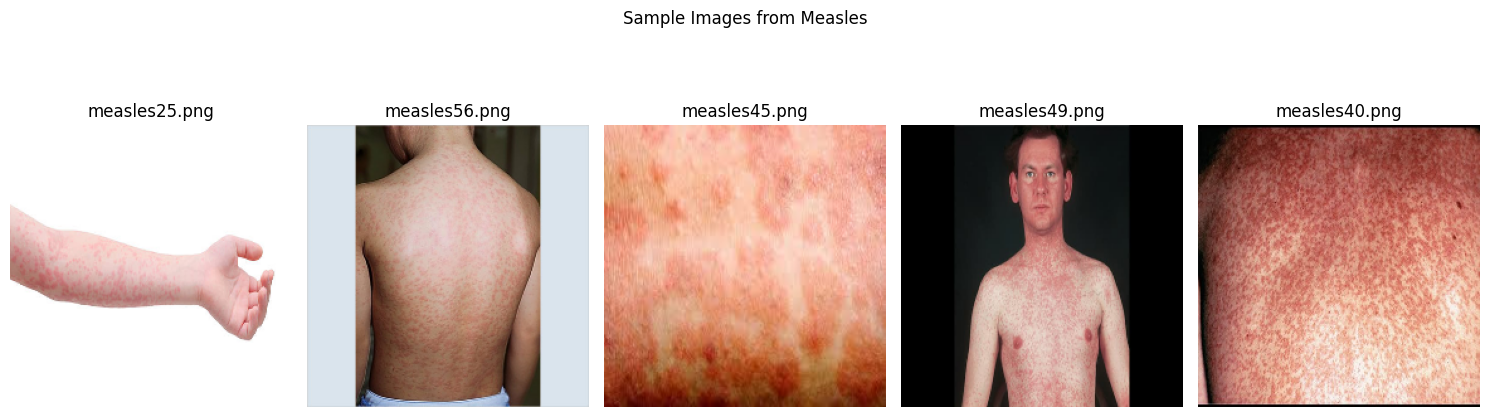

In [ ]:
import random
from PIL import Image, UnidentifiedImageError

def display_images():
    class_names = os.listdir(directory)
    for class_name in class_names:
        class_path = os.path.join(directory, class_name)
        files = os.listdir(class_path)

        if files:
            sample_files = random.sample(files, min(5, len(files))) #choose 5 images
            plt.figure(figsize=(15,5))
            plt.suptitle(f'Sample Images from {class_name}')

            for i, file in enumerate(sample_files):
                file_path = os.path.join(class_path, file)
                try:
                    img = Image.open(file_path)
                    plt.subplot(1, len(sample_files), i + 1)
                    plt.imshow(img)
                    plt.title(file)
                    plt.axis('off')
                except UnidentifiedImageError:
                    print(f"File {file} not valid, skipped.")
                    continue

            plt.tight_layout()
            plt.show()

display_images()

##Preprocessing

In [ ]:
DATASET_DIR = directory
training_datagen = ImageDataGenerator(
    rescale = 1./255,
    validation_split = 0.2)

train_generator = training_datagen.flow_from_directory(
    DATASET_DIR,
    target_size=(224,224),
    class_mode='categorical',
    batch_size=32,
    subset='training')

val_generator = training_datagen.flow_from_directory(
    DATASET_DIR,
    target_size=(224,224),
    class_mode='categorical',
    batch_size=32,
    subset='validation')

Found 618 images belonging to 4 classes.
Found 152 images belonging to 4 classes.


In [ ]:
from tensorflow.keras.applications import DenseNet121

pre_trained_model = DenseNet121(
    include_top=False,
    weights="imagenet",
    input_shape=(224,224, 3))

pre_trained_model.summary()

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "densenet121"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 224, 224, 3)    │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ zero_padding2d            │ (None, 230, 230, 3)    │              0 │ input_layer[0][0]      │
│ (ZeroPadding2D)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_conv (Conv2D)       │ (None, 112, 112, 64)   │          9,408 │ zero_padding2d[0][0]   │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_bn                  │ (None, 112, 112, 64)   │            256 │ conv1_conv[0][0]       │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_relu (Activation)   │ (None, 112, 112, 64)   │              0 │ conv1_bn[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ zero_padding2d_1          │ (None, 114, 114, 64)   │              0 │ conv1_relu[0][0]       │
│ (ZeroPadding2D)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ pool1 (MaxPooling2D)      │ (None, 56, 56, 64)     │              0 │ zero_padding2d_1[0][0] │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_0_bn         │ (None, 56, 56, 64)     │            256 │ pool1[0][0]            │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_0_relu       │ (None, 56, 56, 64)     │              0 │ conv2_block1_0_bn[0][… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_conv       │ (None, 56, 56, 128)    │          8,192 │ conv2_block1_0_relu[0… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_bn         │ (None, 56, 56, 128)    │            512 │ conv2_block1_1_conv[0… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_relu       │ (None, 56, 56, 128)    │              0 │ conv2_block1_1_bn[0][… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_conv       │ (None, 56, 56, 32)     │         36,864 │ conv2_block1_1_relu[0… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_concat       │ (None, 56, 56, 96)     │              0 │ pool1[0][0],           │
│ (Concatenate)             │                        │                │ conv2_block1_2_conv[0… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block2_0_bn    

 Total params: 7,037,504 (26.85 MB)

 Trainable params: 6,953,856 (26.53 MB)

 Non-trainable params: 83,648 (326.75 KB)

In [ ]:
import numpy as np

x_train_list, y_train_list = [], []

for i in range(len(train_generator)):
    x_train_batch, y_train_batch = train_generator[i]
    x_train_list.append(x_train_batch)
    y_train_list.append(y_train_batch)

x_train = np.concatenate(x_train_list)
y_train = np.concatenate(y_train_list)

print('x_train shape:', x_train.shape)
print('y_train shape:', y_train.shape)

x_train shape: (618, 224, 224, 3)
y_train shape: (618, 4)


##K Fold CV

In [ ]:
from sklearn.model_selection import StratifiedKFold
import tensorflow as tf
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

k = 5
skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=1)

acc_per_fold = []
loss_per_fold = []
val_acc_per_fold = []
val_loss_per_fold = []

fold_no = 1

for train_index, val_index in skf.split(x_train, y_train.argmax(1)):
    print(f'Training for fold {fold_no} ...')

    x_train_fold, x_val_fold = x_train[train_index], x_train[val_index]
    y_train_fold, y_val_fold = y_train[train_index], y_train[val_index]

    print(f'Number of training samples: {x_train_fold.shape[0]}')
    print(f'Number of validation samples: {x_val_fold.shape[0]}')

    for layer in pre_trained_model.layers[:-4]:
        layer.trainable = False

    x = pre_trained_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(1024, activation='relu')(x)
    x = Dropout(0.5)(x)
    x = Dense(512, activation='relu')(x)
    x = Dropout(0.3)(x)
    predictions = Dense(4, activation='softmax')(x)

    model = Model(
        inputs=pre_trained_model.input,
        outputs=predictions)

    if fold_no == 1:
        model.summary()

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy'])

    history = model.fit(
        x_train_fold, y_train_fold,
        epochs=50,
        validation_data=(x_val_fold, y_val_fold),
        verbose=1
    )

    scores = model.evaluate(x_val_fold, y_val_fold, verbose=0)
    print(f'Score for fold {fold_no}: {model.metrics_names[0]} of {scores[0]}; {model.metrics_names[1]} of {scores[1]}')

    acc_per_fold.append(scores[1])
    loss_per_fold.append(scores[0])
    val_acc_per_fold.append(history.history['val_accuracy'])
    val_loss_per_fold.append(history.history['val_loss'])

    fold_no += 1

Training for fold 1 ...
Number of training samples: 494
Number of validation samples: 124


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 224, 224, 3)    │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ zero_padding2d            │ (None, 230, 230, 3)    │              0 │ input_layer[0][0]      │
│ (ZeroPadding2D)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_conv (Conv2D)       │ (None, 112, 112, 64)   │          9,408 │ zero_padding2d[0][0]   │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_bn                  │ (None, 112, 112, 64)   │            256 │ conv1_conv[0][0]       │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_relu (Activation)   │ (None, 112, 112, 64)   │              0 │ conv1_bn[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ zero_padding2d_1          │ (None, 114, 114, 64)   │              0 │ conv1_relu[0][0]       │
│ (ZeroPadding2D)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ pool1 (MaxPooling2D)      │ (None, 56, 56, 64)     │              0 │ zero_padding2d_1[0][0] │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_0_bn         │ (None, 56, 56, 64)     │            256 │ pool1[0][0]            │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_0_relu       │ (None, 56, 56, 64)     │              0 │ conv2_block1_0_bn[0][… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_conv       │ (None, 56, 56, 128)    │          8,192 │ conv2_block1_0_relu[0… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_bn         │ (None, 56, 56, 128)    │            512 │ conv2_block1_1_conv[0… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_relu       │ (None, 56, 56, 128)    │              0 │ conv2_block1_1_bn[0][… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_conv       │ (None, 56, 56, 32)     │         36,864 │ conv2_block1_1_relu[0… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_concat       │ (None, 56, 56, 96)     │              0 │ pool1[0][0],           │
│ (Concatenate)             │                        │                │ conv2_block1_2_conv[0… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block2_0_bn    

 Total params: 8,613,956 (32.86 MB)

 Trainable params: 1,615,364 (6.16 MB)

 Non-trainable params: 6,998,592 (26.70 MB)

Epoch 1/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 64s 2s/step - accuracy: 0.4934 - loss: 1.3920 - val_accuracy: 0.7984 - val_loss: 0.6230
Epoch 2/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 33s 100ms/step - accuracy: 0.7585 - loss: 0.6878 - val_accuracy: 0.7500 - val_loss: 0.6349
Epoch 3/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 98ms/step - accuracy: 0.8101 - loss: 0.5523 - val_accuracy: 0.8629 - val_loss: 0.4353
Epoch 4/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 98ms/step - accuracy: 0.8249 - loss: 0.4732 - val_accuracy: 0.8548 - val_loss: 0.4138
Epoch 5/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 108ms/step - accuracy: 0.8873 - loss: 0.3115 - val_accuracy: 0.8226 - val_loss: 0.4071
Epoch 6/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 108ms/step - accuracy: 0.8459 - loss: 0.4171 - val_accuracy: 0.8548 - val_loss: 0.3567
Epoch 7/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 96ms/step - accuracy: 0.8923 - loss: 0.2899 - val_accuracy: 0.8790 - val_loss: 0.3578
Epoch 8/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 97ms/step - accuracy: 0.8912 - loss: 0.2744 - val_accuracy: 0.8710 

In [ ]:
print('------------------------------------------------------------------------')
print('Score per fold')
for i in range(0, len(acc_per_fold)):
    print('------------------------------------------------------------------------')
    print(f'> Fold {i+1} - Loss: {loss_per_fold[i]} - Accuracy: {acc_per_fold[i]}%')
print('------------------------------------------------------------------------')
print('Average scores for all folds:')
print(f'> Accuracy: {np.mean(acc_per_fold)} (+- {np.std(acc_per_fold)})')
print(f'> Loss: {np.mean(loss_per_fold)}')

for i, val_acc in enumerate(val_acc_per_fold):
    print(f'Validation accuracy for fold {i+1}: {val_acc * 100}%')
print('------------------------------------------------------------------------')

------------------------------------------------------------------------
Score per fold
------------------------------------------------------------------------
> Fold 1 - Loss: 0.6649444103240967 - Accuracy: 0.8790322542190552%
------------------------------------------------------------------------
> Fold 2 - Loss: 0.37993335723876953 - Accuracy: 0.9274193644523621%
------------------------------------------------------------------------
> Fold 3 - Loss: 0.5961902737617493 - Accuracy: 0.8870967626571655%
------------------------------------------------------------------------
> Fold 4 - Loss: 0.499165803194046 - Accuracy: 0.8943089246749878%
------------------------------------------------------------------------
> Fold 5 - Loss: 0.16259506344795227 - Accuracy: 0.9674796462059021%
------------------------------------------------------------------------
Average scores for all folds:
> Accuracy: 0.9110673904418946 (+- 0.032653994483043854)
> Loss: 0.46056578159332273
Validation accurac

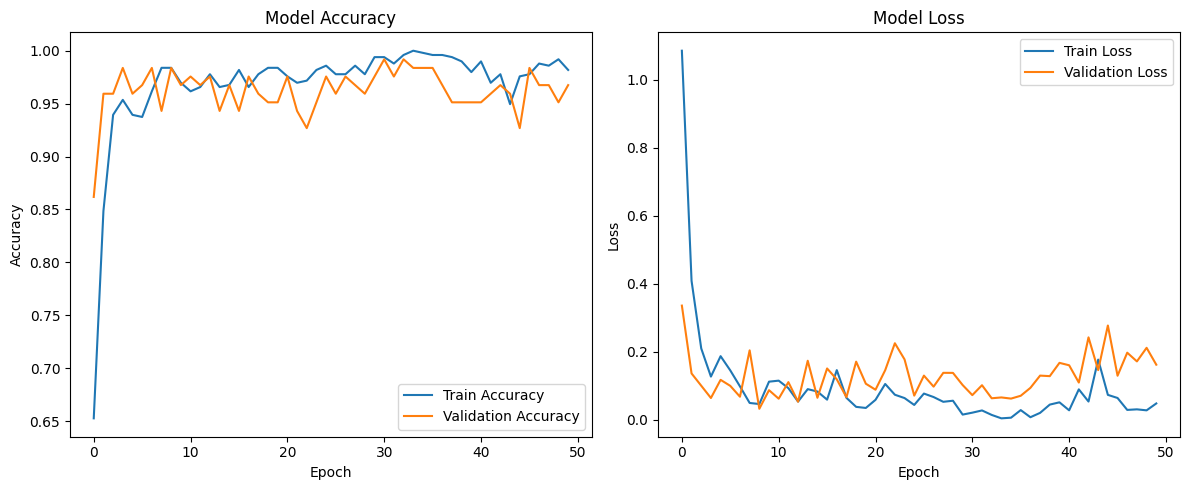

In [ ]:
# Plot akurasi dan loss
plt.figure(figsize=(12, 5))

# Plot akurasi
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='lower right')

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

Shape of x_val: (152, 224, 224, 3)
Shape of y_val: (152, 4)
5/5 ━━━━━━━━━━━━━━━━━━━━ 22s 3s/step
Predicted Classes:  [1 2 3 1 3 1 2 3 3 0 3 3 2 1 0 1 0 1 0 3 2 0 2 3 2 2 0 3 2 2 3 3 1 2 2 3 3
 2 0 3 3 1 3 1 3 2 2 3 1 1 2 3 3 3 2 3 2 3 2 1 2 3 2 3 2 3 1 2 1 0 1 2 3 2
 2 2 2 2 3 2 1 2 1 2 3 2 2 3 2 3 2 3 3 1 2 3 2 3 2 2 2 3 2 0 2 3 2 0 1 3 3
 3 2 3 3 3 2 3 3 0 1 3 3 2 0 2 3 3 2 3 2 2 3 2 0 1 3 2 2 3 3 0 2 3 2 3 1 2
 3 2 3 3]
True Classes:  [1 2 3 1 3 1 2 1 3 0 3 3 2 2 0 0 0 0 0 3 2 0 2 3 2 2 0 3 2 1 3 3 1 2 2 3 3
 2 2 3 3 1 3 1 3 2 2 3 1 2 2 2 3 3 2 3 2 3 0 1 2 3 2 3 2 3 1 2 1 2 1 2 3 2
 2 2 0 2 3 2 1 2 1 2 3 2 2 3 0 3 2 3 3 3 2 3 2 3 2 3 2 3 2 2 0 3 0 0 3 0 3
 3 2 3 3 3 0 3 3 0 1 3 3 2 0 2 3 3 2 3 2 2 3 2 0 0 1 0 2 3 3 2 2 3 2 3 1 2
 3 2 3 3]


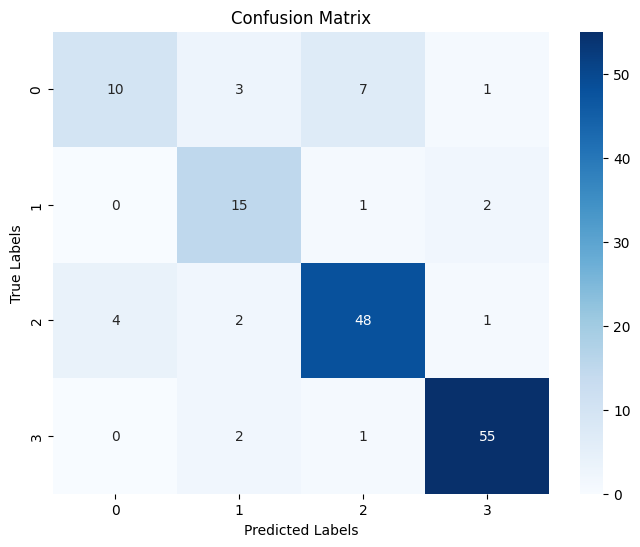

Classification Report:
               precision    recall  f1-score   support

           0       0.71      0.48      0.57        21
           1       0.68      0.83      0.75        18
           2       0.84      0.87      0.86        55
           3       0.93      0.95      0.94        58

    accuracy                           0.84       152
   macro avg       0.79      0.78      0.78       152
weighted avg       0.84      0.84      0.84       152



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

x_val_list = []
y_val_list = []

for i in range(len(val_generator)):
    x_val_batch, y_val_batch = val_generator[i]
    x_val_list.append(x_val_batch)
    y_val_list.append(y_val_batch)

x_val = np.concatenate(x_val_list)
y_val = np.concatenate(y_val_list)

print("Shape of x_val:", x_val.shape)
print("Shape of y_val:", y_val.shape)

y_val_pred = model.predict(x_val)
y_val_pred_classes = np.argmax(y_val_pred, axis=1)
y_val_true_classes = np.argmax(y_val, axis=1)

print("Predicted Classes: ", y_val_pred_classes)
print("True Classes: ", y_val_true_classes)

conf_matrix = confusion_matrix(y_val_true_classes, y_val_pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=range(4), yticklabels=range(4))
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

print("Classification Report:\n", classification_report(y_val_true_classes, y_val_pred_classes))

In [ ]:
model.save("model-mobilenetv2.h5")